In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
from idtxl.estimators_jidt import JidtDiscreteMI, JidtDiscreteCMI
import matplotlib.pyplot as plt
import os, sys
os.environ['JAVA_HOME'] = '/Users/jaime/miniconda3/envs/ma-aif-dit/lib/jvm'

In [117]:
%store -r all_partition_timeseries

## Krakauer et al. individuality

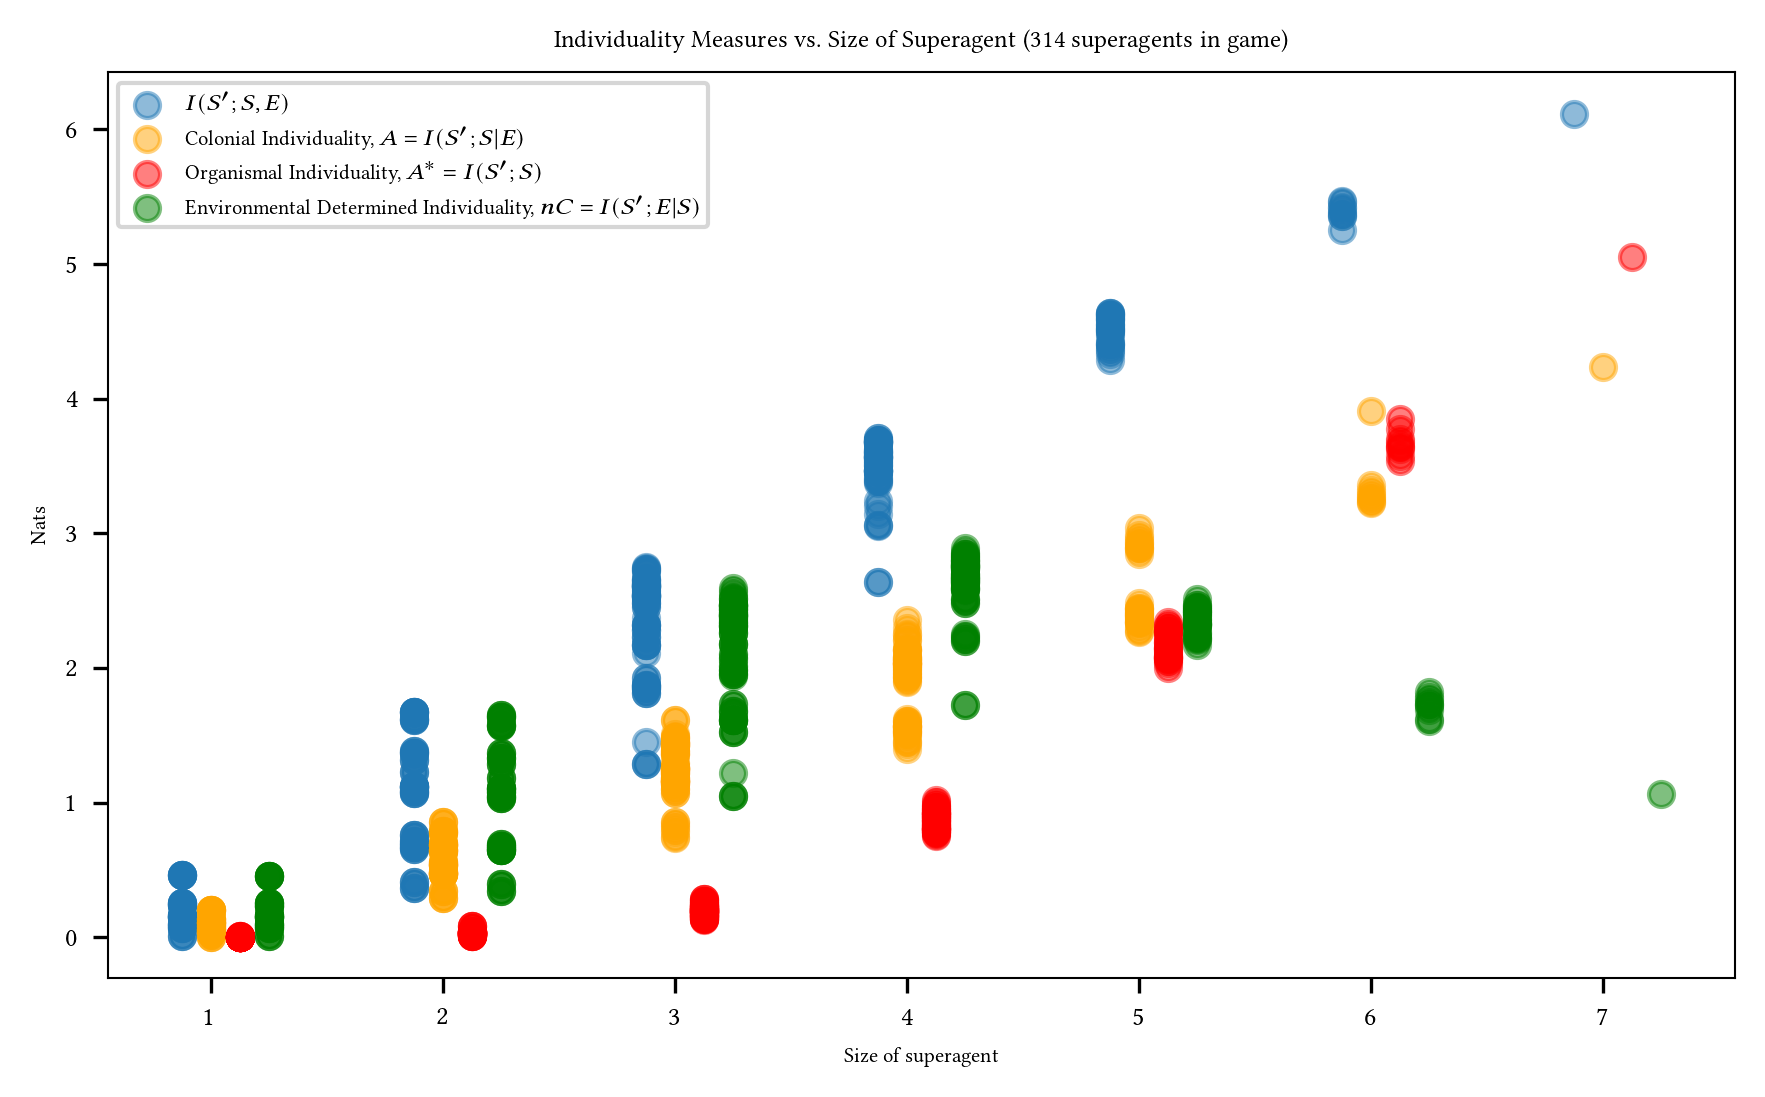

In [118]:
plt.figure(figsize=(7, 4), dpi=150)

plt.rcParams.update({'font.size': 5})

# I(S, E; S') ------------------------------------------------------------------
results_vanilla = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = np.hstack((S_history[:-1], E_history[:-1]))
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_vanilla.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]-0.125 for r in results_vanilla]
y = [r[0] for r in results_vanilla]
plt.scatter(x, y, alpha=0.5, label="$I(S'; S, E)$")

# I(S'; S | E) --------------------------------------------------------------
results_colonial = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=E_history[:-1])
    results_colonial.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1] for r in results_colonial]
y = [r[0] for r in results_colonial]
plt.scatter(x, y, alpha=0.5, c='orange', label="Colonial Individuality, $A = I(S'; S | E)$")

# I(S'; S | E) --------------------------------------------------------------
results_organismal = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_organismal.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.125 for r in results_organismal]
y = [r[0] for r in results_organismal]
plt.scatter(x, y, alpha=0.5, c='red', label="Organismal Individuality, $A^*=I(S' ; S)$")

# I(S'; E | S) --------------------------------------------------------------
results_environmental = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = E_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=S_history[:-1])
    results_environmental.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.25 for r in results_environmental]
y = [r[0] for r in results_environmental]
plt.scatter(x, y, alpha=0.5, c='green', label="Environmental Determined Individuality, $nC=I(S'; E | S)$")

# Create a scatterplot ---------------------------------------------------------
plt.legend()
plt.ylabel('Nats')
plt.xlabel('Size of superagent')
plt.title(f'Individuality Measures vs. Size of Superagent ({len(all_partition_timeseries)} superagents in game)')
plt.show()

## PID individuality

In [119]:
import pandas as pd

from dit import Distribution
from dit.pid import *

In [120]:
unique_infos = []
for S_history, E_history in all_partition_timeseries:
# S_history, E_history = all_partition_timeseries[45]
    print('superagent size', S_history.shape[1])

    # Data setup -------------------------------------------------
    all_data = np.hstack((S_history[:-1], S_history[1:], E_history[:-1], E_history[1:]))

    m = S_history.shape[1]
    if m > 4:
        # Compute struggles with larger superagents
        break

    V = all_data[:, :m].mean(axis=1)

    # Create column names for S_history and E_history
    s_columns = [f"S_{i}" for i in range(S_history.shape[1])]
    s_next_columns = [f"S_{i}_" for i in range(S_history.shape[1])]
    e_columns = [f"E_{i}" for i in range(E_history.shape[1])]
    e_next_columns = [f"E_{i}_" for i in range(E_history.shape[1])]
    column_names = s_columns + s_next_columns + e_columns + e_next_columns + ['V']

    # Combine S_history and E_history into a single DataFrame
    df = pd.DataFrame(
        np.hstack((all_data, V.reshape(-1, 1))), 
        columns=column_names
    )

    # Get distribution from DataFrame
    counts = df.value_counts()
    outcomes = list(counts.index)
    probs = list(counts / counts.sum())
    dist = Distribution(outcomes, probs)

    # Shorthand function to get the index of a column
    idx = lambda x: column_names.index(x)

    # Compute PID ------------------------------------------------------------------
    sources = [
        (idx('V'),), 
        tuple([idx(f'S_{i}') for i in range(m)]), 
    ]
    target = tuple([idx(f'S_{i}_') for i in range(m)])

    pid_obj = PID_BROJA(dist, sources, target)

    # synergy = pid_obj.get_pi(
    #     ( sources[0] + sources[1], ) 
    # )
    # redundancy = pid_obj.get_red(tuple(sources))

    # TODO: level-k
    unique_info = pid_obj.get_pi(
        (sources[1], )
    )
    # unique_info = pid_obj.get_pi(
        # (tuple([idx(f'S_{i}_') for i in range(m)]), )
    # )

    # unique_infos = np.empty((2,))
    # for i in range(2):
    #     unique_infos[i] = pid_obj.get_pi(((i,),))

    # Also compute total MI (sum synergy, redundancy, unique X1, unique X2)
    # total_mi = (
    #     synergy
    #     + redundancy
    #     + unique_infos.sum()
    # )
    unique_infos.append(unique_info)

superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 3


KeyboardInterrupt: 

In [121]:
label_font_size = 6

# matplotlib.use("pgf")
plt.rcParams.update({
    'xtick.labelsize': label_font_size,
    'ytick.labelsize': label_font_size,
    'axes.linewidth': 0.5,
    'font.family': 'serif',
    'text.usetex': True,
    'text.latex.preamble': r'''
        \usepackage{amssymb} 
        \usepackage{amsmath} 

        % Load Libertine fonts for text and math
        \usepackage[tt=false]{libertine}   % Libertine for text (not for monospaced)
        \usepackage[libertine]{newtxmath}  % Libertine for math

        % Load Inconsolata for monospaced text
        \usepackage{inconsolata}

        % Redefine \mathtt to use Inconsolata in math mode
        \renewcommand{\mathtt}[1]{\text{\texttt{#1}}}
    ''',
    'figure.dpi': 300,
    'pgf.texsystem': 'pdflatex',
    'pgf.rcfonts': False,
    'ps.usedistiller': 'xpdf',
})

Text(0.5, 1.0, 'Unique Information vs. Size of Superagent (data for only 13 superagents)')

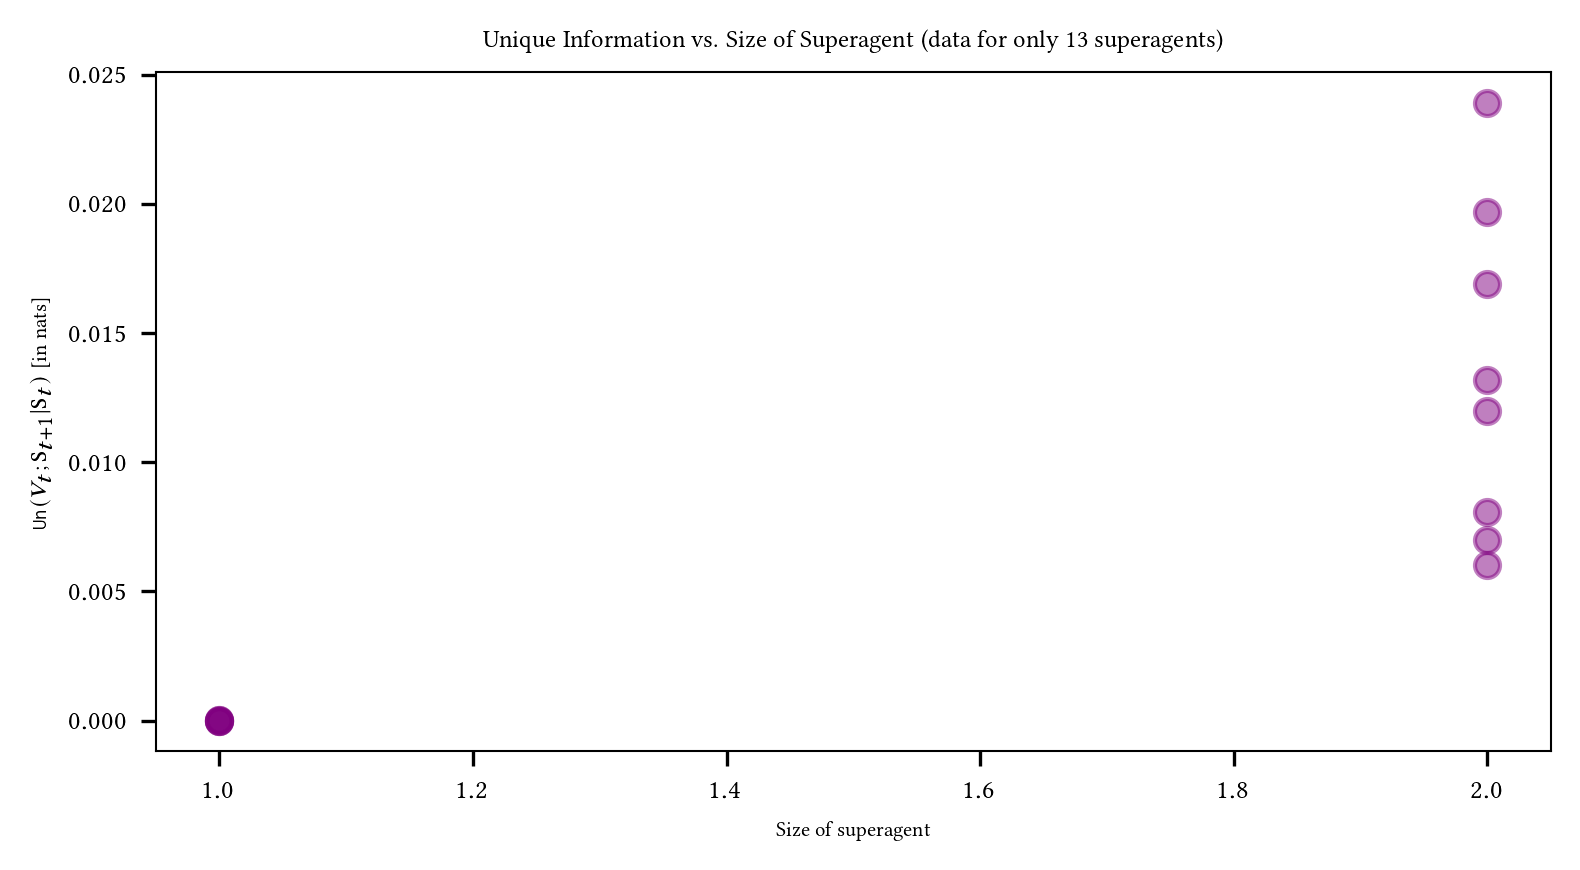

In [122]:
superagent_sizes = np.array([s.shape[1] for s, e in all_partition_timeseries])
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes[:len(unique_infos)], 
    unique_infos, 
    alpha=0.5, 
    c='purple', 
    label="Unique Information"
)
plt.xlabel('Size of superagent')
plt.ylabel(r'$\texttt{Un}(V_t; \mathbf{S}_{t+1} | \mathbf{S}_t)$ [in nats]')
plt.title(f'Unique Information vs. Size of Superagent (data for only {len(unique_infos)} superagents)')

## IIT

The following measure is a sufficient condition for "causal emergence":

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1})
$$

* This is Eq. 10a in [@Rosas2020ReconcilingEmergences](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008289#sec003)
* See also Eq. 1 in [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html)

⚠️ The question remains: how to select the right coarse-graining $V = f(X)$? [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html) addresses this with deep learning.

In [123]:
mappings = {
    'mean': lambda x: x.mean(axis=1),
    'max': lambda x: x.max(axis=1),
    'min': lambda x: x.min(axis=1),
    'std': lambda x: x.std(axis=1),
}

results_psi = {k: [] for k in mappings.keys()}

for key, mapping in mappings.items():
    for S_history, E_history in all_partition_timeseries:
        psi = 0
        
        # First (global) term
        num_bins = 10
        mi_estimator = JidtDiscreteMI(
            settings=dict(n_discrete_bins=num_bins)
        )
        V = mappings[key](S_history)
        # Discretize V
        V = np.digitize(V, bins=np.linspace(V.min(), V.max(), num_bins)).astype(np.int32) - 1
        source = V[:-1]
        target = V[1:]
        mi_result = mi_estimator.estimate(source, target)

        psi += mi_result
        
        # Second (local) term
        for i in range(S_history.shape[1]):
            mi_estimator = JidtDiscreteMI(
                settings=dict(n_discrete_bins=num_bins)
            )
            source = S_history[:-1, i]
            target = V[1:]
            mi_result = mi_estimator.estimate(source, target)
            psi -= mi_result

        results_psi[key].append(psi)

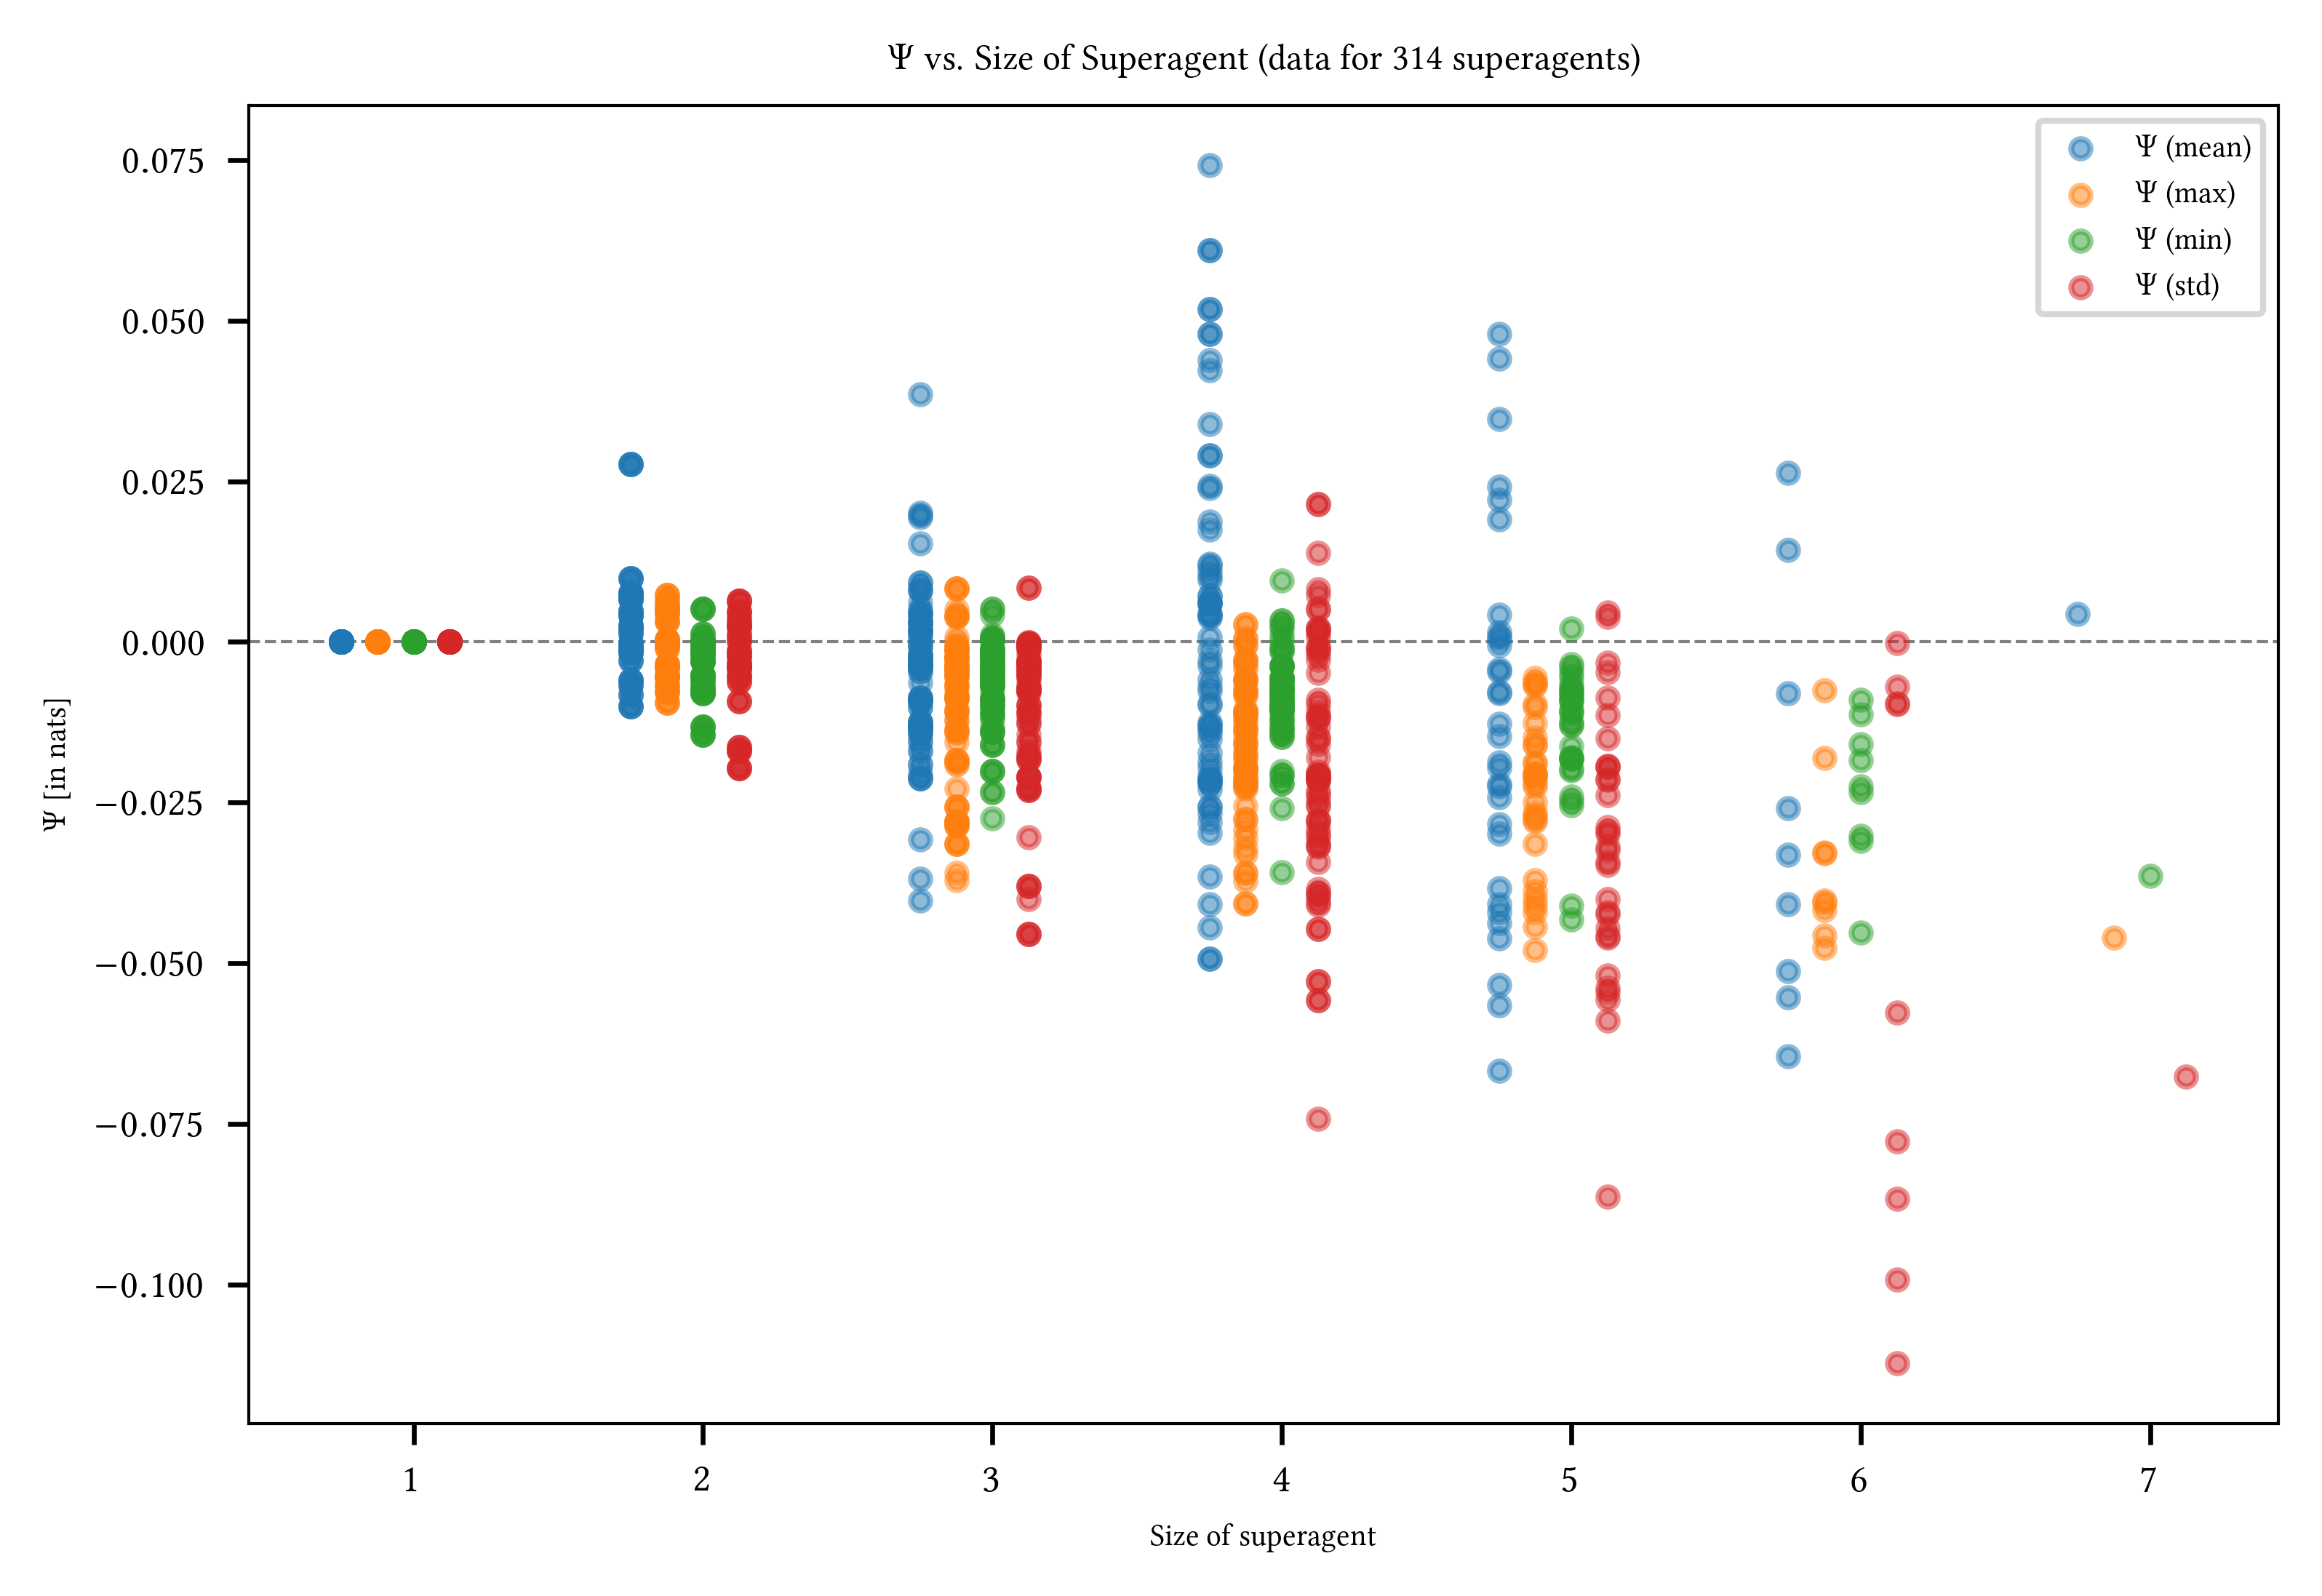

In [124]:
results_psi = {
    k: np.array(v) for k, v in results_psi.items()
}

jitters = np.arange(-0.25, 0.25, 0.125)
for i, (key, result) in enumerate(results_psi.items()):
    plt.scatter(
        superagent_sizes[:len(result)] + jitters[i], 
        result, 
        alpha=0.5, 
        s=10,
        label=f"$\Psi$ ({key})"
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)

plt.xlabel('Size of superagent')
plt.ylabel(r'$\Psi$ [in nats]')
plt.title(f'$\Psi$ vs. Size of Superagent (data for {len(results_psi[list(results_psi.keys())[0]])} superagents)')
plt.legend()
plt.show()

### Minimum Mutual Information-adjusted measure

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1}) + (n-1)\min_i I(X^i_t; V_{t+1})
$$

* Eq. 2 in [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html)

In [125]:
mappings = {
    'mean': lambda x: x.mean(axis=1),
    'max': lambda x: x.max(axis=1),
    'min': lambda x: x.min(axis=1),
    'std': lambda x: x.std(axis=1),
}

results_psi = {k: [] for k in mappings.keys()}

for key, mapping in mappings.items():
    for S_history, E_history in all_partition_timeseries:
        psi = 0
        
        # First (global) term
        num_bins = 10
        mi_estimator = JidtDiscreteMI(
            settings=dict(n_discrete_bins=num_bins)
        )
        V = mappings[key](S_history)
        # Discretize V
        V = np.digitize(V, bins=np.linspace(V.min(), V.max(), num_bins)).astype(np.int32) - 1
        source = V[:-1]
        target = V[1:]
        mi_result = mi_estimator.estimate(source, target)

        psi += mi_result
        
        # Second (local) term
        local_mi_results = []
        for i in range(S_history.shape[1]):
            mi_estimator = JidtDiscreteMI(
                settings=dict(n_discrete_bins=num_bins)
            )
            source = S_history[:-1, i]
            target = V[1:]
            mi_result = mi_estimator.estimate(source, target)
            local_mi_results.append(mi_result)
            psi -= mi_result

        # Third term: MMI adjustment
        local_mi_results = np.array(local_mi_results)
        psi += len(local_mi_results) * local_mi_results.min()

        results_psi[key].append(psi)

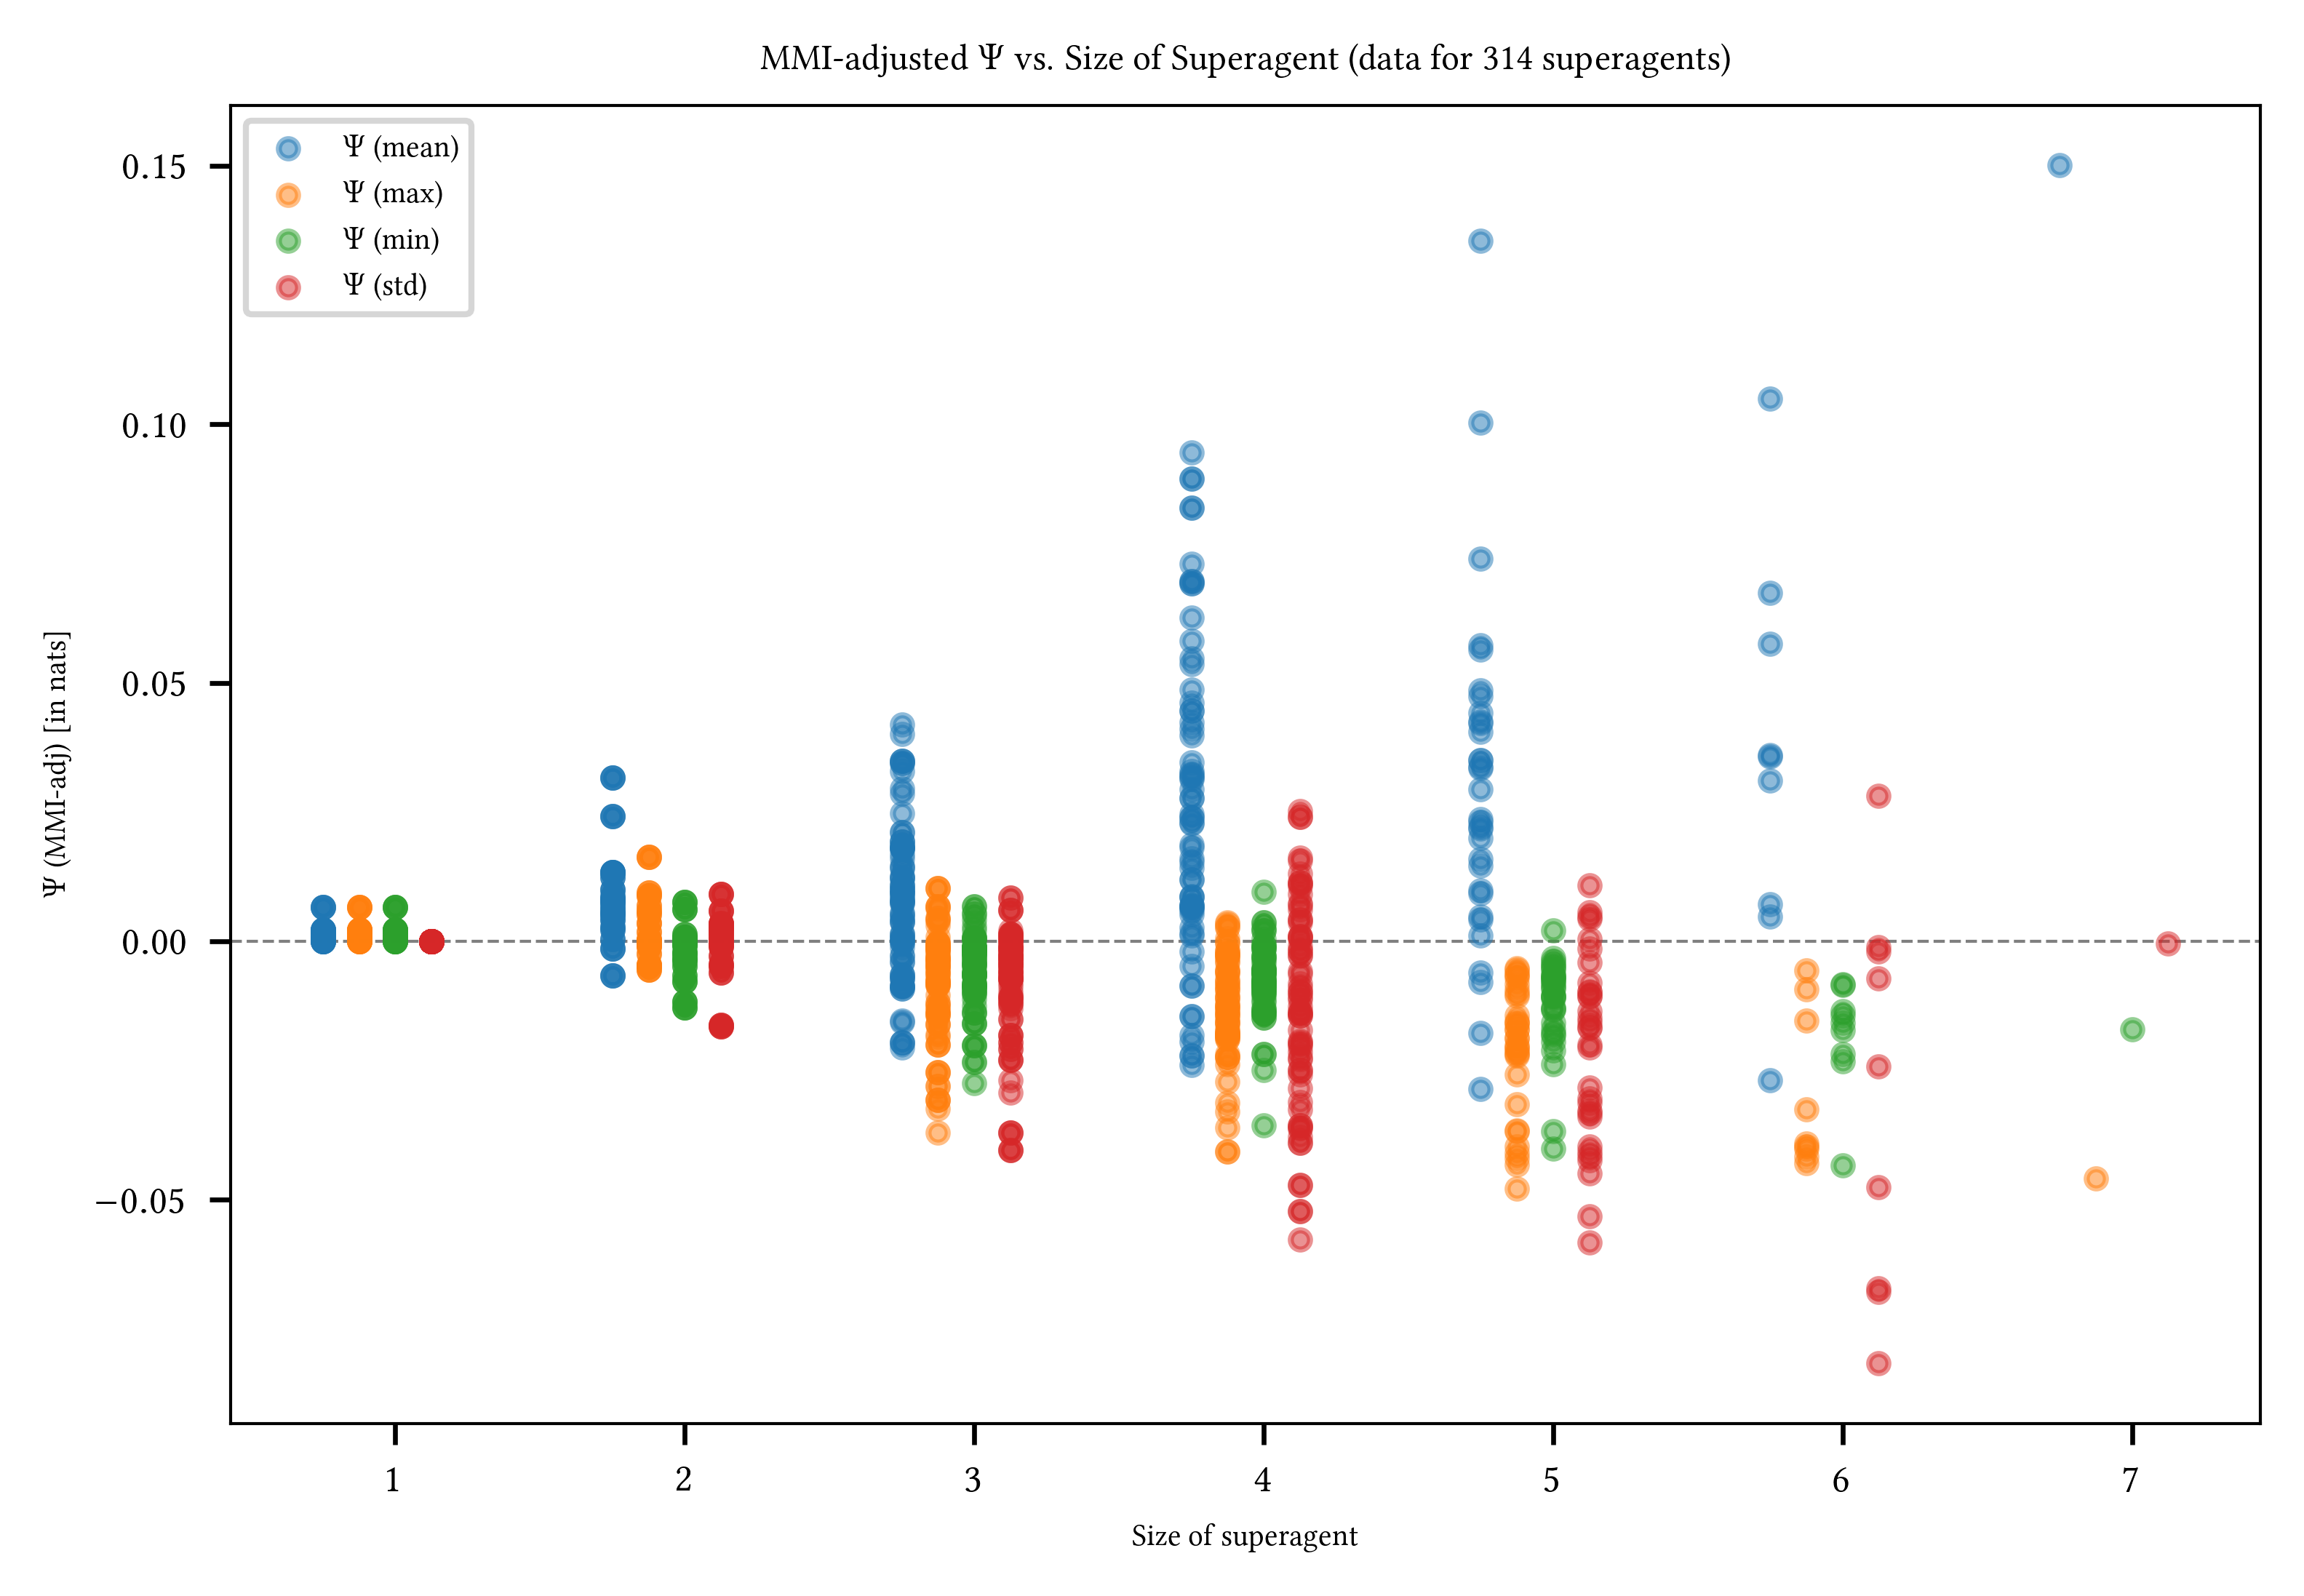

In [126]:
results_psi = {
    k: np.array(v) for k, v in results_psi.items()
}

jitters = np.arange(-0.25, 0.25, 0.125)
for i, (key, result) in enumerate(results_psi.items()):
    plt.scatter(
        superagent_sizes[:len(result)] + jitters[i], 
        result, 
        alpha=0.5, 
        s=10,
        label=f"$\Psi$ ({key})"
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)

plt.xlabel('Size of superagent')
plt.ylabel(r'$\Psi$ (MMI-adj) [in nats]')
plt.title(f'MMI-adjusted $\Psi$ vs. Size of Superagent (data for {len(results_psi[list(results_psi.keys())[0]])} superagents)')
plt.legend()
plt.show()

## IDEA: optimise linear coarse-graining function $V$ w.r.t. $\Psi$

Let:
$$
V = \sum_i w_i X^i
$$

Optimise $w_i$ w.r.t. $\Psi$.

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1})
$$

In [127]:
from scipy.optimize import minimize

# Define the objective function for optimization
def psi_objective(w, X, num_bins=10):
    """
    Objective function to minimize Psi = I(V_t; V_{t+1}) - sum_i I(X^i_t; V_{t+1})
    """
    # Compute V = sum_i w_i * X^i
    V = X @ w

    # Discretize V
    V_discretized = np.digitize(V, bins=np.linspace(V.min(), V.max(), num_bins)).astype(np.int32) - 1

    # Compute the first term: I(V_t; V_{t+1})
    mi_estimator = JidtDiscreteMI(settings=dict(n_discrete_bins=num_bins))
    source = V_discretized[:-1]
    target = V_discretized[1:]
    I_Vt_Vt1 = mi_estimator.estimate(source, target)

    # Compute the second term: sum_i I(X^i_t; V_{t+1})
    I_Xi_Vt1_sum = 0
    for i in range(X.shape[1]):
        source = X[:-1, i]
        target = V_discretized[1:]
        I_Xi_Vt1_sum += mi_estimator.estimate(source, target)

    # Compute Psi
    psi = I_Vt_Vt1 - I_Xi_Vt1_sum
    return -psi  # Minimize negative Psi to maximize Psi

In [128]:
for superagent_idx in range(len(all_partition_timeseries)):

    data = all_partition_timeseries[superagent_idx]
    X = data[0]
    Y = data[1]

    # Initialize weights
    num_features = X.shape[1]
    initial_weights = np.ones(num_features) / num_features

    # Optimize weights
    result = minimize(psi_objective, initial_weights, args=(X), method='L-BFGS-B', bounds=[(0, 1)] * num_features)

    # Extract optimized weights
    optimized_weights = result.x
    print("Optimized weights:", optimized_weights)

    # Compute the final V using the optimized weights
    V_optimized = X @ optimized_weights

Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.25 0.25 0.25 0.25]
Optimized weights: [0.25 0.25 0.25 0.25]
Optimized weights: [0.25 0

## epsilon Machines, D-BaSS

In [129]:
from collections import Counter
import numpy as np

In [158]:
from collections import Counter
import numpy as np

def estimate_conditional_probabilities(X, Y, L=1):
    '''
    Estimate p(x' | x_L, y_L)
    '''
        
    X_subsequences = np.array([X[t-L:t] for t in range(L, len(X))])  # shape: (T-L+1, L, n)
    Y_subsequences = np.array([Y[t-L:t] for t in range(L, len(Y))])  # shape: (T-L+1, L, m)

    # Flatten subsequences for input to the model
    X_sub_flat = X_subsequences.reshape(X_subsequences.shape[0], -1)  # shape: (T-L+1, L*n)
    Y_sub_flat = Y_subsequences.reshape(Y_subsequences.shape[0], -1)  # shape: (T-L+1, L*m)

    # Combine X_sub and Y_sub as features
    features = np.hstack((X_sub_flat, Y_sub_flat))  # { X_{t-L:t}, Y_{t-L:t} }  shape: (T-L+1, L*n + L*m)

    # Target is the current state X
    targets = X[L:]  # { X_{t} }  shape: (T-L+1, n)

    # Convert features and targets to tuples for counting
    features_tuples = [tuple(f) for f in features]
    target_tuples = [tuple(t) for t in targets]

    # Count occurrences of each feature-target pair, and of each feature
    joint_counts = Counter(zip(features_tuples, target_tuples))
    feature_counts = Counter(features_tuples)

    # Generate the support for the probability distribution
    n = X.shape[1]
    dist_support = (
        np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)])
    )  # shape: (2^n, n) e.g. [[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], ...] for n=3

    # Estimate conditional probabilities
    conditional_probs = {
        feature: np.zeros(len(dist_support)) 
        for feature in feature_counts.keys()
    }
    for (feature, target), joint_count in joint_counts.items():
        target_index = np.where((dist_support == target).all(axis=1))[0][0]
        # print(feature, target, joint_count, feature_counts[feature])
        conditional_probs[feature][target_index] = joint_count / feature_counts[feature]

    return dist_support, conditional_probs

In [159]:
# Data preparation
# superagent_idx = 30
for superagent_idx in [10]:#range(len(all_partition_timeseries)):
    data = all_partition_timeseries[superagent_idx]
    X = data[0]
    Y = data[1]

    # print(f'Superagent {superagent_idx} size: {X.shape[1]}, Immediate environment size: {Y.shape[1]}')

    dist_support, conditional_probs = estimate_conditional_probabilities(X, Y, L=1)
    for feature, prob in conditional_probs.items():
        print(f"Feature {feature}: {prob}")

    

    # print(f'Superagent {superagent_idx} size: {X.shape[1]}, Immediate environment size: {Y.shape[1]}')

Feature (0, 1, 0, 1, 0, 0, 0, 1, 0): [0.  0.  0.5 0.5]
Feature (1, 1, 0, 0, 0, 1, 0, 1, 1): [1. 0. 0. 0.]
Feature (0, 0, 0, 1, 0, 0, 1, 0, 0): [0.  0.5 0.  0.5]
Feature (1, 1, 1, 0, 1, 1, 1, 0, 1): [0. 1. 0. 0.]
Feature (0, 1, 1, 0, 1, 0, 0, 1, 1): [0. 0. 0. 1.]
Feature (1, 1, 1, 0, 0, 0, 0, 0, 1): [0. 0. 0. 1.]
Feature (1, 1, 0, 1, 0, 1, 1, 1, 0): [0. 0. 0. 1.]
Feature (1, 1, 0, 0, 1, 1, 0, 1, 0): [0.5 0.  0.  0.5]
Feature (1, 1, 0, 0, 1, 1, 0, 1, 1): [0.  0.5 0.  0.5]
Feature (0, 1, 0, 1, 0, 1, 0, 0, 0): [1. 0. 0. 0.]
Feature (0, 0, 0, 1, 1, 0, 1, 0, 1): [1. 0. 0. 0.]
Feature (0, 0, 1, 1, 1, 1, 0, 1, 1): [0. 1. 0. 0.]
Feature (0, 1, 0, 1, 0, 0, 0, 0, 0): [0.33333333 0.33333333 0.33333333 0.        ]
Feature (1, 0, 0, 1, 1, 0, 0, 0, 1): [0. 0. 0. 1.]
Feature (1, 1, 1, 0, 0, 1, 0, 1, 0): [1. 0. 0. 0.]
Feature (0, 0, 0, 1, 1, 0, 1, 1, 1): [1. 0. 0. 0.]
Feature (0, 0, 0, 0, 1, 1, 0, 1, 0): [1. 0. 0. 0.]
Feature (0, 0, 0, 1, 0, 0, 0, 0, 1): [0. 1. 0. 0.]
Feature (1, 0, 1, 1, 0, 0, 1, 1, 0

In [132]:
conditional_probs

{(0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  1): array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 (1,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  1): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 (0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0): array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 (1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  0): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 (1,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  1): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 (1,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  0): array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 (0,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1): array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 (0,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  1): array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 (1,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  1): ar

## Empowerment

$$
\mathfrak{E} \triangleq C(A_t \to S_{t+1}) \equiv \max_{p(a_t)} I(S_{t+1}; A_t)
$$

ModuleNotFoundError: No module named 'idtxl.mutual_information'

In [ ]:
# --- Example Usage ---
# Generate some sample multivariate data
num_samples = 500
num_s_vars = 2  # e.g., position (x, y)
num_a_vars = 2  # e.g., force (fx, fy)

np.random.seed(123)
a_data = np.random.randn(num_samples, num_a_vars) * 5 # Random actions

# Create simple dynamics: S_{t+1} = S_t + 0.1*A_t + noise
s_data = np.zeros((num_samples, num_s_vars))
noise_std = 0.5
integration_factor = 0.1
for t in range(num_samples - 1):
    # Assume action affects acceleration, integrate simply
    # Ensure action dimension matches state dimension influence if necessary
    # Here, let's assume A[0] influences S[0], A[1] influences S[1]
    s_data[t+1, :] = s_data[t, :] + integration_factor * a_data[t, :num_s_vars] + np.random.normal(0, noise_std, size=num_s_vars)

# --- Compute the MI ---
mi_s_next_a_current = compute_multivariate_mi_s_next_a_current(s_data, a_data, k=5, verbose=False)

if mi_s_next_a_current is not None:
    print(f"\nEstimated Multivariate Mutual Information I(S_t+1 ; A_t) = {mi_s_next_a_current:.4f} nats")
    print("\nReminder: This measures the information based on observed data, not 'Empowerment'.")
else:
    print("\nFailed to compute Mutual Information.")

# --- Example with mismatched dimensions (should raise error) ---
# print("\n--- Testing Mismatched Samples Error ---")
# try:
#     s_short = s_data[:-10, :]
#     compute_multivariate_mi_s_next_a_current(s_short, a_data)
# except ValueError as e:
#     print(f"Caught expected error: {e}")